# Assignment 2 - Metabolic modeling

KEN3170, group 13: Sava Stoimenov, Ben Tickler, Barnabás Szaniszló, Sofia Tsankova

Files: e_coli_core.json (model from BiGG), KEN3170_Assignment_2026_e_coli_core_expression.csv (max reaction activities in mmol/gDW/h)

In [1]:
import csv
import cobra
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model = cobra.io.load_json_model('e_coli_core.json')
print(f'{len(model.reactions)} reactions, {len(model.metabolites)} metabolites, {len(model.genes)} genes')

95 reactions, 72 metabolites, 137 genes


In [2]:
# read the max activity data into a dict {reaction_id: value}
activity = {}
with open('KEN3170_Assignment_2026_e_coli_core_expression.csv', mode='r', newline='') as file:
    reader = csv.reader(file)
    for row in reader:
        if not row or row[0].startswith('#'):   # skip empty lines and the header
            continue
        activity[row[0].strip()] = float(row[1])

print(f'{len(activity)} reactions with activity data')
missing = [rid for rid in activity if rid not in model.reactions]
print('IDs not found in the model:', missing)

65 reactions with activity data
IDs not found in the model: []


## Task 1

We loaded the csv on the online Escher map (Data -> Load reaction data). The same map is built here with the escher python package so it is in the notebook too: the html file is the interactive version, the svg below is a static export of it (made with the "Export as SVG" option). Arrow thickness and colour = max activity, grey = 0 or no data.

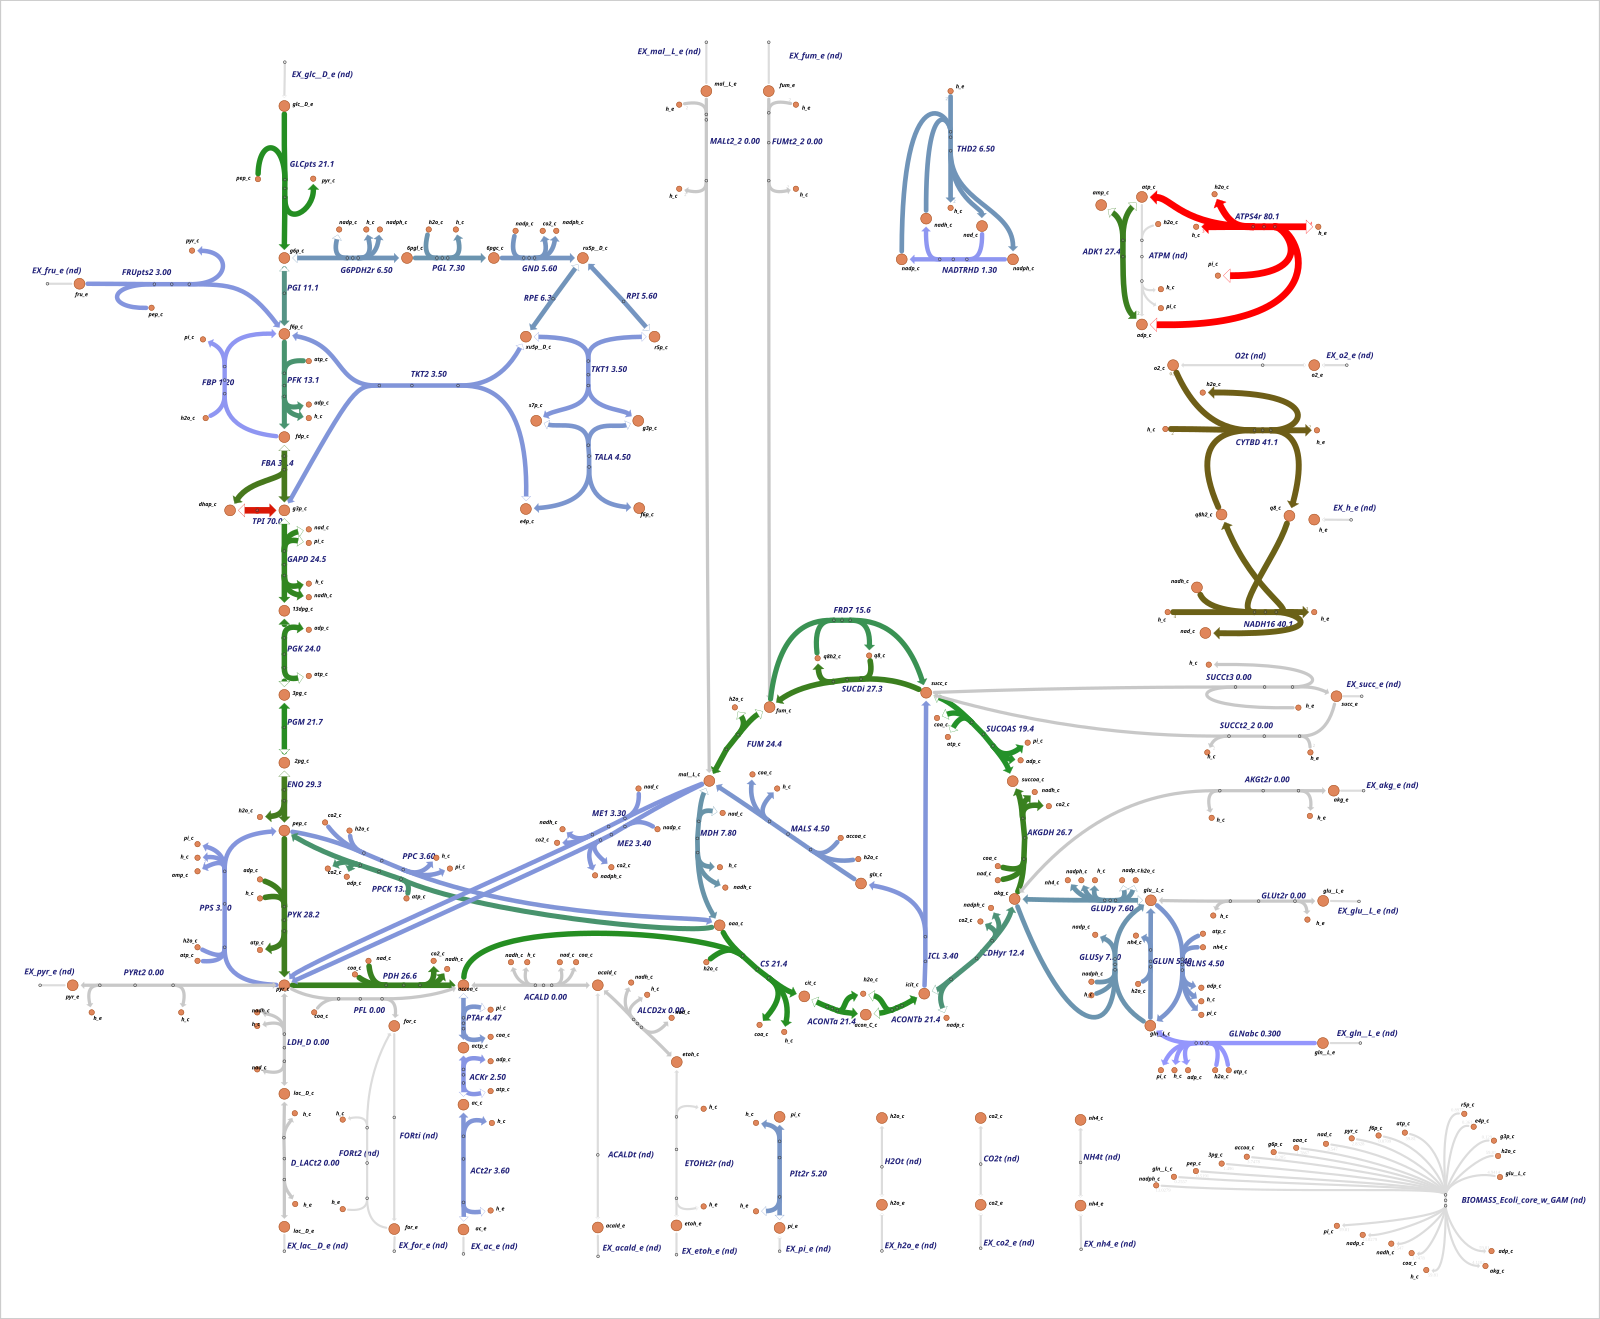

In [3]:
import escher
from IPython.display import SVG

escher.rc['never_ask_before_loading'] = True
builder = escher.Builder(map_name='e_coli_core.Core metabolism', model_name='e_coli_core',
                         reaction_data=activity)
builder.save_html('escher_max_activity.html')   # interactive map, open in a browser

SVG('escher_max_activity.svg')

In [4]:
# 1a: values along the linear part of glycolysis
glycolysis = ['GLCpts', 'PGI', 'PFK', 'FBA', 'TPI', 'GAPD', 'PGK', 'PGM', 'ENO', 'PYK']
pd.DataFrame({'reaction': glycolysis,
              'max activity [mmol/gDW/h]': [activity[r] for r in glycolysis]})

,reaction,max activity [mmol/gDW/h]
0,GLCpts,21.1
1,PGI,11.1
2,PFK,13.1
3,FBA,30.4
4,TPI,70.0
5,GAPD,24.5
6,PGK,24.0
7,PGM,21.7
8,ENO,29.3
9,PYK,28.2


In [5]:
# 1b: the two kinds of grey reactions on the map
zero_valued = sorted(rid for rid, v in activity.items() if v == 0)
no_data     = sorted(r.id for r in model.reactions if r.id not in activity)
print(f'Value 0 in the data ({len(zero_valued)}):', zero_valued)
print(f'\nNo data at all ({len(no_data)}):', no_data)

Value 0 in the data (12): ['ACALD', 'AKGt2r', 'ALCD2x', 'D_LACt2', 'FUMt2_2', 'GLUt2r', 'LDH_D', 'MALt2_2', 'PFL', 'PYRt2', 'SUCCt2_2', 'SUCCt3']

No data at all (30): ['ACALDt', 'ATPM', 'BIOMASS_Ecoli_core_w_GAM', 'CO2t', 'ETOHt2r', 'EX_ac_e', 'EX_acald_e', 'EX_akg_e', 'EX_co2_e', 'EX_etoh_e', 'EX_for_e', 'EX_fru_e', 'EX_fum_e', 'EX_glc__D_e', 'EX_gln__L_e', 'EX_glu__L_e', 'EX_h2o_e', 'EX_h_e', 'EX_lac__D_e', 'EX_mal__L_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e', 'EX_pyr_e', 'EX_succ_e', 'FORt', 'FORt2', 'H2Ot', 'NH4t', 'O2t']


1a) No. In the practical the fluxes along a linear pathway were equal because of mass balance (what is produced has to be consumed). The values here are not fluxes, they are enzyme capacities estimated per reaction from expression, so nothing forces neighbours to match. Along glycolysis they jump around (PGI 11.1, PFK 13.1, FBA 30.4, TPI 70 ...). The actual flux through the pathway is limited by the smallest capacity, the rest of the enzymes are in excess.

1b) Two different cases give grey arrows:

- value 0 (shows "0"): reaction is in the file but not expressed, e.g. PFL, LDH_D, ALCD2x, PYRt2. The reaction is blocked, this is a real constraint.
- no data (shows "nd"): reaction is not in the file at all, e.g. all EX_ reactions, transporters like O2t and CO2t, ATPM, biomass. These are not enzyme reactions so there is no expression value, they just keep their default bounds.

## Task 2

Rules: reversible -> (-v, v), irreversible -> (0, v), no data -> default bounds. EX_glc__D_e gets the default -1000 instead of -10. ATPM is not in the file so its lower bound (8.39) is never touched.

In [6]:
def apply_activity_constraints(model, activity):
    """Set flux bounds from max reaction activities (in place)."""
    for rid, v in activity.items():
        rxn = model.reactions.get_by_id(rid)
        if rxn.reversibility:              # lower_bound < 0 in the base model
            rxn.bounds = (-v, v)
        else:                              # irreversible: keep lower bound at 0
            rxn.bounds = (0, v)

constrained = model.copy()
apply_activity_constraints(constrained, activity)

# glucose exchange: remove the default uptake limit, use the high default bound
constrained.reactions.EX_glc__D_e.bounds = (-1000, 1000)

print('EX_glc__D_e:', constrained.reactions.EX_glc__D_e.bounds)
print('ATPM      :', constrained.reactions.ATPM.bounds)

EX_glc__D_e: (-1000, 1000)
ATPM      : (8.39, 1000.0)


In [7]:
bounds_table = pd.DataFrame(
    [(r.id, r.lower_bound, r.upper_bound, activity.get(r.id, np.nan)) for r in constrained.reactions],
    columns=['reaction', 'lower_bound', 'upper_bound', 'max_activity'])

pd.set_option('display.max_rows', None)
bounds_table

,reaction,lower_bound,upper_bound,max_activity
0,PFK,0.00,13.10,13.10
1,PFL,0.00,0.00,0.00
2,PGI,-11.10,11.10,11.10
3,PGK,-24.00,24.00,24.00
4,PGL,0.00,7.30,7.30
5,ACALD,-0.00,0.00,0.00
6,AKGt2r,-0.00,0.00,0.00
7,PGM,-21.70,21.70,21.70
8,PIt2r,-5.20,5.20,5.20
9,ALCD2x,-0.00,0.00,0.00


NaN in max_activity = no data, default bounds kept. Reactions with value 0 end up with bounds (0, 0), so they are knocked out.

## Task 3

In [8]:
# 3a: FBA with the expression-based constraints only
sol_a = constrained.optimize()
print('status:', sol_a.status)
print(f'max biomass production rate: {sol_a.objective_value:.4f} /h')
print(f'glucose uptake in the optimum: {-sol_a.fluxes["EX_glc__D_e"]:.3f} mmol/gDW/h')

exch_a = sol_a.fluxes[[r.id for r in constrained.exchanges]]
exch_a[exch_a.abs() > 1e-6].round(3)

status: optimal
max biomass production rate: 0.8733 /h
glucose uptake in the optimum: 10.620 mmol/gDW/h


EX_ac_e         2.500
EX_co2_e       21.560
EX_glc__D_e   -10.620
EX_h_e         20.018
EX_h2o_e       27.921
EX_nh4_e       -4.762
EX_o2_e       -20.550
EX_pi_e        -3.213
Name: fluxes, dtype: float64

3a) Max growth rate is 0.873 /h. Glucose is unlimited, so uptake (~10.6) is set by what the enzymes can handle. The limiting ones are the respiratory chain (CYTBD sits at its cap of 41.1) and acetate export (ACKr at 2.5), the leftover carbon goes out as acetate.

In [9]:
# 3b: put back an absolute glucose exchange bound of 5 mmol/gDW/h (uptake direction)
constrained_glc5 = constrained.copy()
constrained_glc5.reactions.EX_glc__D_e.lower_bound = -5
print('EX_glc__D_e:', constrained_glc5.reactions.EX_glc__D_e.bounds)

EX_glc__D_e: (-5, 1000)


3b) The glucose bound describes the environment: how much substrate is available / can be taken up from the medium. The expression bounds describe the cell itself: how much flux each enzyme can carry. One limits the input, the other limits what the network can do with it.

In [10]:
# 3c: FBA with both constraint types
sol_c = constrained_glc5.optimize()
print('status:', sol_c.status)
print(f'max biomass production rate: {sol_c.objective_value:.4f} /h')
print(f'glucose uptake in the optimum: {-sol_c.fluxes["EX_glc__D_e"]:.3f} mmol/gDW/h')

pd.DataFrame({'3a: expression only': exch_a,
              '3c: expression + glc <= 5': sol_c.fluxes[exch_a.index]}).loc[
    lambda d: (d.abs() > 1e-6).any(axis=1)].round(3)

status: optimal
max biomass production rate: 0.4156 /h
glucose uptake in the optimum: 5.000 mmol/gDW/h


,3a: expression only,3c: expression + glc <= 5
EX_ac_e,2.500,0.000
EX_co2_e,21.560,12.314
EX_glc__D_e,-10.620,-5.000
EX_h_e,20.018,8.337
EX_h2o_e,27.921,15.341
EX_nh4_e,-4.762,-2.266
EX_o2_e,-20.550,-11.834
EX_pi_e,-3.213,-1.529


3c) Growth drops from 0.873 to 0.416 /h. Uptake went from ~10.6 to 5, so about half the carbon, and growth roughly halves with it. Now glucose is the bottleneck, not the enzymes: respiration has enough capacity for all of it, so no acetate is secreted anymore and less O2, NH4 and Pi are used.